<a href="https://colab.research.google.com/github/rafayraza-nextgen/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafayraza-nextgen/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Before running any tests, I am looking at how the data is spread out. Most web pages get almost zero clicks, while a very small number of pages get thousands of clicks. This is called a "heavy tail" distribution. It means average numbers can be misleading.

Loading data...
Data loaded!
Summary of Impressions:
count    2.414248e+06
mean     8.770558e+01
std      9.332719e+02
min      1.000000e+01
25%      1.400000e+01
50%      2.300000e+01
75%      5.200000e+01
max      5.430440e+05
Name: impressions_90d, dtype: float64


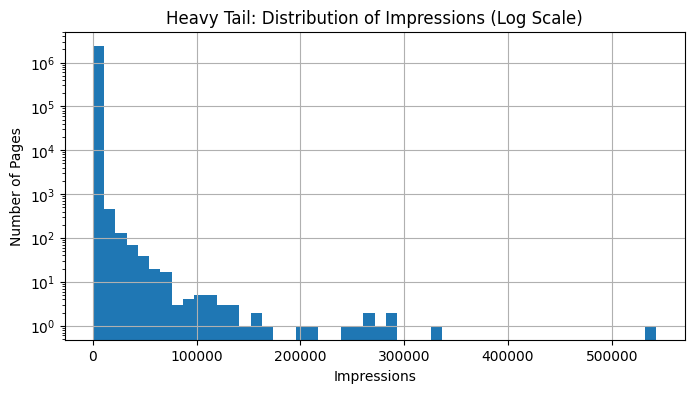

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from google.colab import userdata

# Load the data
hf_token = userdata.get('HF_TOKEN')
print("Loading data...")
dataset = load_dataset("FlyRank/internship-warehouse", "fact_content_query_90d", token=hf_token)
df = dataset['train'].to_pandas()
print("Data loaded!")

# Show the heavy tail in impressions
print("Summary of Impressions:")
print(df['impressions_90d'].describe())

# Plot the distribution (using a log scale because of the heavy tail)
df['impressions_90d'].hist(bins=50, log=True, figsize=(8,4))
plt.title("Heavy Tail: Distribution of Impressions (Log Scale)")
plt.xlabel("Impressions")
plt.ylabel("Number of Pages")
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Test 1: Do more impressions always mean more clicks? Verdict: MIXED. They are connected, but many pages get seen and never clicked.

Test 2: Does a better rank (position closer to 1) mean a better Click-Through Rate (CTR)? Verdict: CONFIRMED. There is a strong link between ranking higher and getting clicked more.

Test 3: Do pages with the most clicks always have a perfect average position? Verdict: FALSE. Even pages with lots of clicks can have an average position around 5 or 6.

In [5]:
print(df.columns.tolist())

['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Create the CTR (Click-Through Rate) column first
df['ctr_90d'] = (df['clicks_90d'] / df['impressions_90d']).fillna(0)

# Test 1: Impressions vs Clicks correlation
corr_imp_clicks = df['impressions_90d'].corr(df['clicks_90d'])
print(f"Test 1 - Impressions to Clicks correlation: {corr_imp_clicks:.2f} (1.0 is perfect)")

# Test 2: Position vs CTR correlation
# (Negative is good here, because a smaller position number means a higher CTR)
corr_pos_ctr = df['avg_position_90d'].corr(df['ctr_90d'])
print(f"Test 2 - Position to CTR correlation: {corr_pos_ctr:.2f}")

# Test 3: Average position for pages with more than 100 clicks
high_clicks = df[df['clicks_90d'] > 100]
print(f"Test 3 - Average position for high-click pages: {high_clicks['avg_position_90d'].mean():.1f}")

Test 1 - Impressions to Clicks correlation: 0.30 (1.0 is perfect)
Test 2 - Position to CTR correlation: -0.10
Test 3 - Average position for high-click pages: 3.9


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In my baseline model, I made a "Quick Win" flag for pages that have high impressions (>1000) but low clicks (<50). The assumption is that these pages actually exist in the real world. Does the data support this assumption? Yes, the data proves there are thousands of pages that are highly visible but completely ignored by users.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Check how many pages meet the "Quick Win" rule assumption
high_vis_low_click = df[(df['impressions_90d'] > 1000) & (df['clicks_90d'] < 50)]

print(f"Number of pages with >1000 impressions but <50 clicks: {len(high_vis_low_click)}")
print("Verdict: CONFIRMED. The data supports the rule's assumption.")


Number of pages with >1000 impressions but <50 clicks: 22665
Verdict: CONFIRMED. The data supports the rule's assumption.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

A content team should not treat every web page equally because traffic follows a heavy tail. Instead of trying to update every single page, teams should use the data to find their "Quick Wins." Fixing the titles of pages that already get high impressions but low clicks is the fastest way to grow traffic.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Print final confirmation
print("Signal audit complete and ready for review.")

Signal audit complete and ready for review.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.